In [54]:
import numpy as np

def f(x):
    return x**2+4*x+4

def grad_fx(x):
    return 2*x+4 


x = np.linspace(-14, 10, 100)
y = f(x)

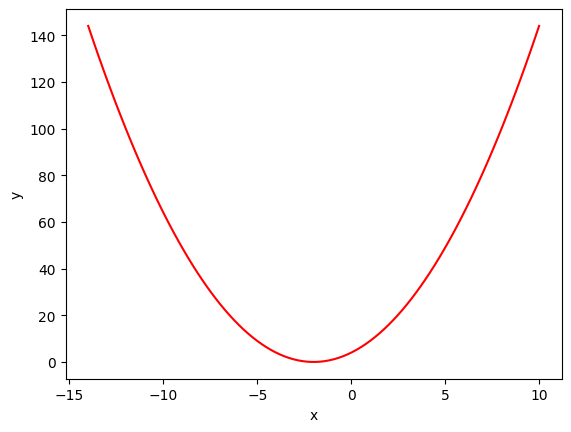

In [55]:
import matplotlib.pyplot as plt

plt.plot(x, y, color='red')
plt.xlabel("x")
plt.ylabel("y")

plt.show()


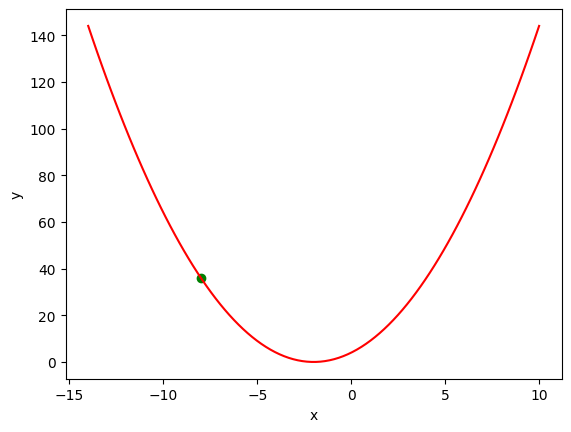

-12


In [56]:
x0 = np.random.randint(low=-10, high=10)
y0 = f(x0)
x0, y0

import matplotlib.pyplot as plt


plt.plot(x, y, color='red')
plt.xlabel("x")
plt.ylabel("y")

plt.scatter(x0, y0, c='green')

plt.show()
print(grad_fx(x0))


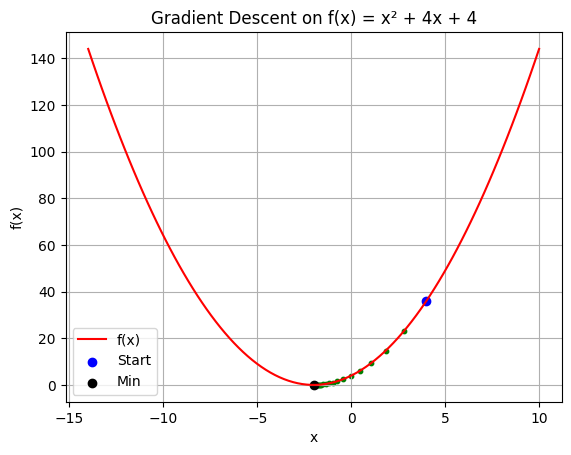

Minimum at x = -2.0000, f(x) = 0.0000


In [101]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
lr = 0.1
tol = 1e-5
iterations = 1000

# Function and its derivative
def f(x):
    return x**2 + 4*x + 4

def grad_fx(x):
    return 2*x + 4

# Plot the function
x_vals = np.linspace(-14, 10, 100)
y_vals = f(x_vals)
plt.plot(x_vals, y_vals, color='red', label='f(x)')

# Starting point
x0 = np.random.randint(-10, 10)
y0 = f(x0)
plt.scatter(x0, y0, color='blue', label='Start')

# Gradient Descent
for _ in range(iterations):
    grad = grad_fx(x0)
    if abs(grad) < tol:
        break
    x0 = x0 - lr * grad
    y0 = f(x0)
    plt.scatter(x0, y0, color='green', s=10)

plt.scatter(x0, y0, color='black', label='Min')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.title("Gradient Descent on f(x) = x² + 4x + 4")
plt.grid(True)
plt.show()

print(f"Minimum at x = {x0:.4f}, f(x) = {y0:.4f}")


### for two variable function


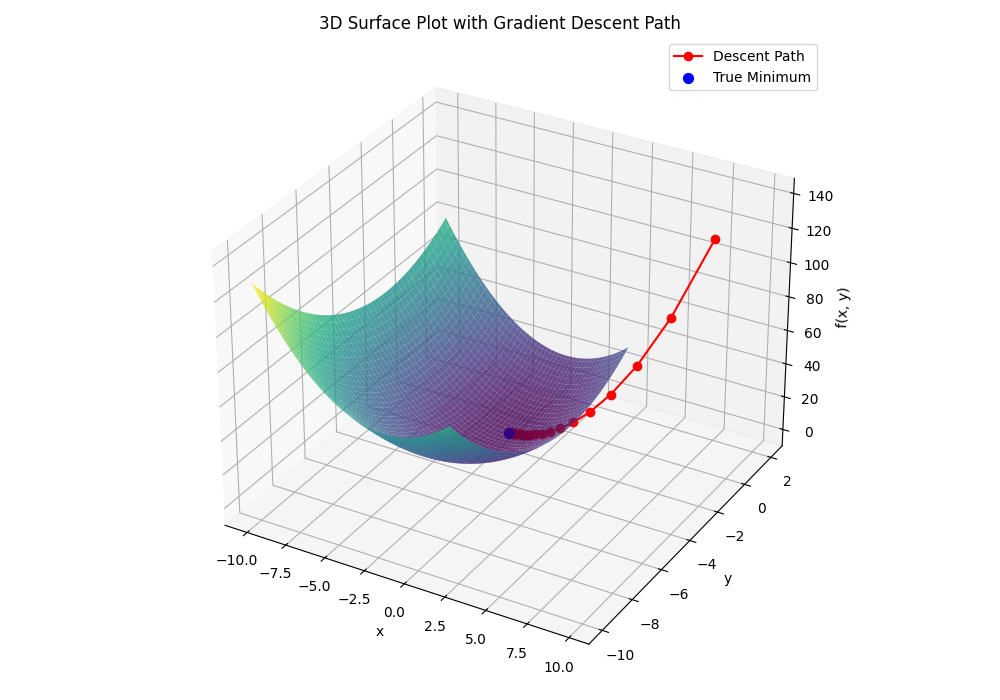

Converged to x = [-1.99999529 -1.99999963], f(x) = 0.0000


In [107]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt


# Define the function
def f(vec):
    x, y = vec
    return x**2 + y**2 + 4*x + 4*y + 8

# Gradient of the function
def grad_f(vec):
    x, y = vec
    return np.array([2*x + 4, 2*y + 4])

# Hyperparameters
lr = 0.1
tol = 1e-5
max_iter = 1000

# Starting point
x = np.random.uniform(-10, 10, size=2)
path = [x.copy()]  # Store path

# Gradient Descent Loop
for _ in range(max_iter):
    grad = grad_f(x)
    if np.linalg.norm(grad) < tol:
        break
    x = x - lr * grad
    path.append(x.copy())

path = np.array(path)

# Prepare surface grid
x_vals = np.linspace(-10, 2, 100)
y_vals = np.linspace(-10, 2, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + Y**2 + 4*X + 4*Y + 8

# 3D Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')

# Plot gradient descent path
Z_path = np.array([f(p) for p in path])
ax.plot(path[:, 0], path[:, 1], Z_path, color='red', marker='o', label='Descent Path')

# Plot minimum
ax.scatter(-2, -2, f([-2, -2]), color='blue', s=50, label='True Minimum')

# Labels and formatting
ax.set_title("3D Surface Plot with Gradient Descent Path")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Converged to x = {x}, f(x) = {f(x):.4f}")


### for  linear regression

In [131]:
# load data

import pandas as pd

df = pd.read_csv(r'data\advertising.csv')
x = df['TV'].values
y = df['Sales'].values


In [134]:
# Use standardization + safer init + smaller step
from sklearn.preprocessing import StandardScaler

x_raw = df[['TV']].values
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_raw)
n = len(x_scaled)
x = np.c_[np.ones((n, 1)), x_scaled]
y = df['Sales'].values.ravel()

step_size = 0.01
iterations = 10000
tol = 1e-6
coef = np.random.randn(x.shape[1])  # safer init


for i in range(iterations):
    y_pred = x @ coef
    errors = y - y_pred
    gradients = -2/n * (x.T @ errors)
    if np.linalg.norm(gradients) < tol:
        print(f"Converged at iteration {i}")
        break
    coef -= step_size * gradients

print("Coefficients (standardized TV):", coef)


Converged at iteration 854
Coefficients (standardized TV): [15.13049952  4.74996575]
